In [1]:
import pandas as pd
import os
import copy
from tqdm import tqdm
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATASET = os.path.join(
    "..","data"
)
CHENNAI_DATASET = os.path.join(DATASET,"Chennai_data")
CORE_TAXA = os.path.join(
    DATASET,
    "MetaSUB_data",
)
RESULTS = os.path.join(
    "..","results"
)
SUPPLEMENTARY = os.path.join(RESULTS, "supplementary")
os.makedirs(SUPPLEMENTARY, exist_ok = True)

threshold = 0.001
MIN_SAMPLES = 12
bounds = [0.97, 0.8] 
peri = 0.15

core_species_dict = {}

In [3]:
def prevalence_extractor(df, bounds=[], col_not_to_include = []):
    taxa_df = copy.copy(df)
    taxa_list = [i for i in taxa_df.columns if i not in col_not_to_include]

    for i in taxa_list:
        taxa_df[i] = taxa_df[i] > 0
        taxa_df[i] = taxa_df[i] * 1

    v = taxa_df[taxa_list].sum() / taxa_df.shape[0]
    v = v.to_frame()
    v = v.reset_index()
    v.rename(columns={"index": "Species", 0: "prevalence"}, inplace=True)
    #v["Species"] = v["Species"].str.replace("prev_", "")
    v.sort_values('prevalence', ascending = False, inplace = True)
    core_df = v.query("prevalence > @bounds[0]")
    sub_core_df = v.query("prevalence > @bounds[1] and prevalence < @bounds[0]")
    peripheral_df = v.query("prevalence < @peri and prevalence > 0.00001")
    v = v.rename(columns={'prevalence':'prevalence'})
    return v, core_df, sub_core_df, peripheral_df

def merger_function(taxa_df, metadata_df):
    taxa_temp = copy.copy(taxa_df)
    taxa_meta = copy.copy(metadata_df)
    taxa_temp = taxa_temp.merge(
        taxa_meta, how="inner", left_on="Samples", right_on="uuid"
    )
    return taxa_temp

def filter_all_zero(df1, col_not_to_include=["Samples"]):
    df = copy.copy(df1)
    col_list = [i for i in df.columns if i not in col_not_to_include]
    temp = df[col_list].sum().to_frame()#.reset_index()
    temp.rename(columns={0: "non_zeros"}, inplace=True)
    #print("before ", df.shape)
    ## The name of the species which are not having any read mapped. These columns can be dropped
    
    df = df.drop(
        columns=list(temp.query("non_zeros<=0.000001").index.values)
    )  
    return df


In [4]:
METADATA = os.path.join(CORE_TAXA,"Filtered_complete_metadata.csv",)
metadata_df = pd.read_csv(METADATA)
metasub_species = pd.read_csv(os.path.join(CORE_TAXA, 'Filtered_bracken_species_non_human_processed.csv'))

s_list = [i for i in metasub_species.columns if i != 'Samples']
print('Core apply threshold')
metasub_species[s_list] = metasub_species[s_list].applymap(lambda x: 0 if x < threshold else x)
#metasub_species = metasub_species.apply(abd_threshold, axis=1)
print('Core filter all zero',metasub_species.shape)

metasub_species = filter_all_zero(metasub_species)
print('after Core filter all zero',metasub_species.shape)

print('Core merge metadata')
metasub_species = merger_function(metasub_species, metadata_df)
print("Merged metasub species shape:", metasub_species.shape)
## Filter the cities based on number of samples
vc = metasub_species['city'].value_counts()
filtered_vc = vc[vc >= MIN_SAMPLES]
temp_filtered_metasub = metasub_species[metasub_species['city'].isin(filtered_vc.index)]
print("Filtered metasub species shape:", temp_filtered_metasub.shape)

col_not_to_include=["Samples","uuid",
                        "core_project",
                        "project",
                        "city",
                        "surface_material",
                        "continent",
                        "surface_ontology_fine",
                        "control_type",]

print("Iterate through each cities")
prevalence_list = []


Core apply threshold
Core filter all zero (2515, 8282)
after Core filter all zero (2515, 3077)
Core merge metadata
Merged metasub species shape: (2515, 3085)
Filtered metasub species shape: (2461, 3085)
Iterate through each cities


In [5]:
## Chennai spl core

Che_spl_core = set(["Sphingobium yanoikuyae",
"Brachybacterium sp. SGAir0954",
"Brachybacterium saurashtrense",
"Pseudomonas alcaligenes",
"Staphylococcus arlettae",
"Brachybacterium sp. P6-10-X1",
"Pseudomonas mendocina",
"Brachybacterium faecium",
"Comamonas aquatica",
])


In [6]:
## Bootstrap
## ORIGINAL
#city = "hong_kong"
## Cities for which we have to do the bootstrap
## Cities that have more than 41 samples
no_of_samples = 41
bs_cities = filtered_vc[filtered_vc > no_of_samples]
city_dict = {}
city_pres_dict = {}
city_common_species_dict = {}

for city in bs_cities.index:

    BS_core_species_dict = {}
    BS_common_species_dict = {}
    city_species_df = metasub_species.query('city == @city')
    presence_of_chennai_spl_core_in_bs = []
    for i in range(100):
        sampled_df = city_species_df.sample(n=no_of_samples)
        sampled_df = filter_all_zero(sampled_df, col_not_to_include=col_not_to_include)
        temp_prev, _core_df, _sub_core_df, _peripheral_df = prevalence_extractor(sampled_df, bounds=bounds, col_not_to_include = col_not_to_include)
        BS_core_species_dict[f"bs_{i}"] = { 
                                        'core':list(_core_df["Species"].values),
                                        'sub_core':list(_sub_core_df["Species"].values),
                                        'peripheral':list(_peripheral_df["Species"].values) 
                                        } 
        # Combine core and sub-core species list
        combined_set = set(list(_core_df["Species"].values) + list(_sub_core_df["Species"].values))
        if len(set(Che_spl_core).intersection(combined_set)) > 0:
            presence_of_chennai_spl_core_in_bs.append(1)
            BS_common_species_dict[f"bs_{i}"] = list(set(Che_spl_core).intersection(combined_set))
        else:
            presence_of_chennai_spl_core_in_bs.append(0)

    city_dict[city] = BS_core_species_dict
    city_pres_dict[city] = presence_of_chennai_spl_core_in_bs
    city_common_species_dict[city] = BS_common_species_dict
        


In [7]:
# ## COntrolled for samples
# ## Bootstrap
# #city = "hong_kong"
# ## Cities for which we have to do the bootstrap
# ## Cities that have more than 41 samples



# metasub_complete = pd.read_csv(os.path.join(CORE_TAXA,"complete_metadata.csv",))
# metasub_surface_df = pd.merge(metasub_species, metasub_complete[["uuid","surface"]], left_on = "Samples", right_on = "uuid", how = "inner")
# metasub_surface_df.drop(columns = ["uuid_y","uuid_x"], inplace = True)
# print(metasub_species.shape, metasub_surface_df.shape)

# surface_to_keep = ['kiosk','handrail','escalator_handrail','ticket_machine','touchscreen','pole','ticket machine']


# ## See if we control for the sample collection object type to the most
# ## if we control for this, does this have a differnt resutl
# metasub_surface_df = metasub_surface_df[metasub_surface_df["surface"].isin(surface_to_keep)]
# print(metasub_surface_df.shape)
# vc = metasub_surface_df['city'].value_counts()
# filtered_vc = vc[vc >= MIN_SAMPLES]
# temp_filtered_metasub = metasub_surface_df[metasub_surface_df['city'].isin(filtered_vc.index)]
# print("Filtered metasub species shape:", temp_filtered_metasub.shape)



# no_of_samples = 41
# bs_cities = filtered_vc[filtered_vc > no_of_samples]
# city_dict = {}
# city_pres_dict = {}
# city_common_species_dict = {}
# col_not_to_include = ["Samples","uuid",
#                         "core_project",
#                         "project",
#                         "city",
#                         "surface_material",
#                         "continent",
#                         "surface_ontology_fine",
#                         "control_type","surface"]
# for city in bs_cities.index:

#     BS_core_species_dict = {}
#     BS_common_species_dict = {}
#     city_species_df = metasub_surface_df.query('city == @city')
#     presence_of_chennai_spl_core_in_bs = []
#     for i in range(100):
#         sampled_df = city_species_df.sample(n=no_of_samples)
#         sampled_df = filter_all_zero(sampled_df, col_not_to_include=col_not_to_include)
#         temp_prev, _core_df, _sub_core_df, _peripheral_df = prevalence_extractor(sampled_df, bounds=bounds, col_not_to_include = col_not_to_include)
#         BS_core_species_dict[f"bs_{i}"] = { 
#                                         'core':list(_core_df["Species"].values),
#                                         'sub_core':list(_sub_core_df["Species"].values),
#                                         'peripheral':list(_peripheral_df["Species"].values) 
#                                         } 
#         # Combine core and sub-core species list
#         combined_set = set(list(_core_df["Species"].values) + list(_sub_core_df["Species"].values))
#         if len(set(Che_spl_core).intersection(combined_set)) > 0:
#             presence_of_chennai_spl_core_in_bs.append(1)
#             BS_common_species_dict[f"bs_{i}"] = list(set(Che_spl_core).intersection(combined_set))
#         else:
#             presence_of_chennai_spl_core_in_bs.append(0)

#     city_dict[city] = BS_core_species_dict
#     city_pres_dict[city] = presence_of_chennai_spl_core_in_bs
#     city_common_species_dict[city] = BS_common_species_dict
        


In [8]:
for city_,pres_ in city_pres_dict.items():
    if max(pres_) > 0:
        print(f"{city_} has presence of Chennai spl core in its bootstrap samples")


ilorin has presence of Chennai spl core in its bootstrap samples


In [9]:
print(city_dict["hong_kong"]["bs_0"]["core"])
print(city_dict["hong_kong"]["bs_10"]["core"])

['Bradyrhizobium sp. BTAi1', 'Cutibacterium acnes', 'Micrococcus luteus']
['Bradyrhizobium sp. BTAi1', 'Cutibacterium acnes']


In [10]:
city_common_species_dict

{'hong_kong': {},
 'london': {},
 'ilorin': {'bs_99': ['Pseudomonas mendocina']},
 'singapore': {},
 'new_york_city': {},
 'porto': {},
 'barcelona': {},
 'kyiv': {},
 'doha': {},
 'seoul': {},
 'zurich': {},
 'lisbon': {},
 'stockholm': {}}

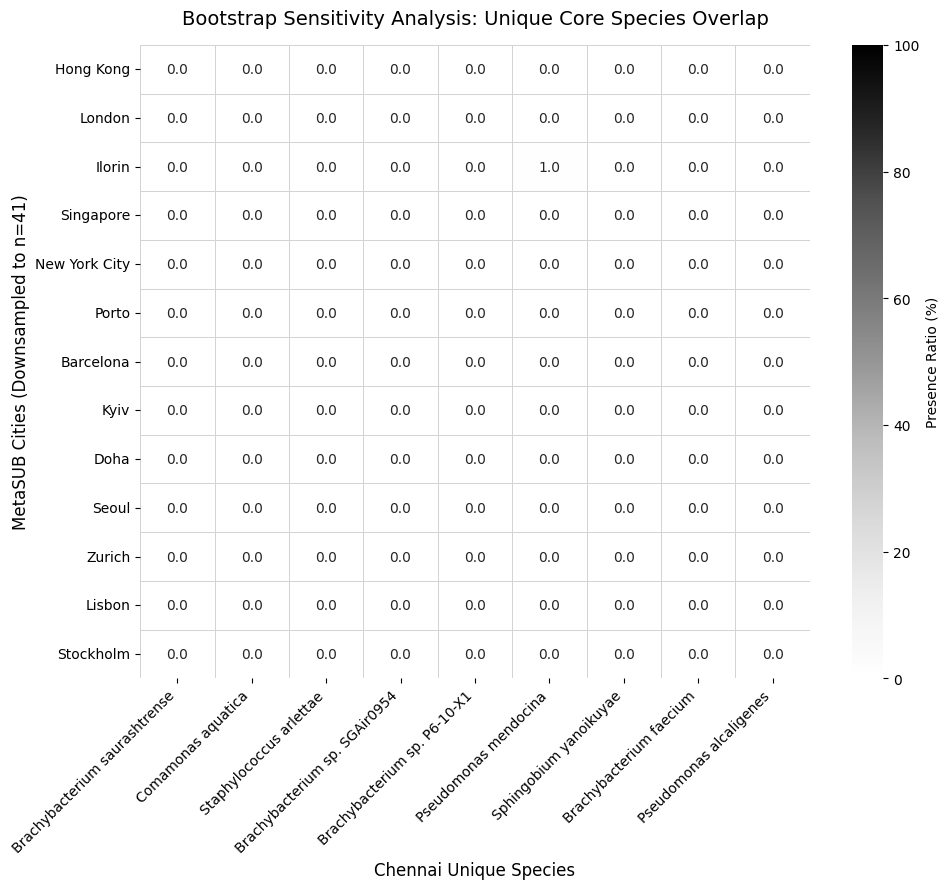

In [14]:
# Your input dictionary from the bootstrap runs
bootstrap_results = city_common_species_dict

# 5 illustrative species (drawn from the Chennai unique-core findings)
target_species = list(Che_spl_core)

total_runs = 100

# Initialize an empty matrix with zeros (Rows = Cities, Columns = Species)
cities = [i.replace("_"," ").title() for i in list(bootstrap_results.keys())]
count_matrix = pd.DataFrame(0.0, index=cities, columns=target_species)

# Populate the matrix with the occurrence counts
for city, runs in bootstrap_results.items():
    for run_id, species_list in runs.items():
        for species in species_list:
            if species in target_species:
                city = city.replace("_"," ").title()
                count_matrix.at[city, species] += 1

# Convert raw counts to a presence_ratio (percentage out of total runs)
presence_ratio_matrix = (count_matrix / total_runs) * 100

# Set up the visualization
plt.figure(figsize=(10, 9))

# Create the heatmap
ax = sns.heatmap(
    presence_ratio_matrix,
    annot=True,          # Displays the numeric value in each cell
    fmt=".1f",           # Formats the annotation to 1 decimal place
    cmap="Greys",        # A grayscale colormap emphasizes the 'sea of zeros'
    cbar_kws={'label': 'Presence Ratio (%)'},
    linewidths=0.5,      # Adds gridlines to make empty cells distinct
    linecolor='lightgray',
    vmin=0,              # Anchor the color scale at 0
    vmax=100             # Max possible ratio is 100%
)

# Formatting labels and titles
plt.title('Bootstrap Sensitivity Analysis: Unique Core Species Overlap', fontsize=14, pad=15)
plt.ylabel('MetaSUB Cities (Downsampled to n=41)', fontsize=12)
plt.xlabel('Chennai Unique Species', fontsize=12)
plt.xticks(rotation=45, ha='right') # Tilt x-axis labels for readability

plt.tight_layout()

plt.savefig(os.path.join("..","figures",f'Figure_bootstrap_sensitivity_analysis.pdf'), dpi=600, bbox_inches='tight')
plt.show()